In [3]:
import os
import sys

os.chdir("..")
sys.path.append(os.getcwd())

In [4]:
from src.Preprocessing import get_preprocessed_data
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [5]:
X_train, X_test, y_train, y_test = get_preprocessed_data()

print(X_train.shape)
print(X_test.shape)

(68395, 36)
(9408, 36)


# Random Forest

In [6]:
for depth in [15, 20, 30]:
    for n in [100, 200, 300]:

        rf = RandomForestRegressor(
            n_estimators=n,
            max_depth=depth,
            random_state=42,
            n_jobs=-1
        )

        rf.fit(X_train, y_train)
        y_pred = rf.predict(X_test)

        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        print(f"n={n}, depth={depth}")
        print("RMSE:", rmse)
        print("R2:", r2)
        print("---------")

n=100, depth=15
RMSE: 0.2279962633240993
R2: 0.8551276913889766
---------
n=200, depth=15
RMSE: 0.2282145678735601
R2: 0.854850130480276
---------
n=300, depth=15
RMSE: 0.22837630029995892
R2: 0.8546443262744924
---------
n=100, depth=20
RMSE: 0.21836406696031163
R2: 0.8671100093590309
---------
n=200, depth=20
RMSE: 0.2173285272720841
R2: 0.8683674191815206
---------
n=300, depth=20
RMSE: 0.21700001072749456
R2: 0.8687650733454977
---------
n=100, depth=30
RMSE: 0.21600803059732746
R2: 0.8699621690074067
---------
n=200, depth=30
RMSE: 0.2152054948176239
R2: 0.8709266345149699
---------
n=300, depth=30
RMSE: 0.215052303428747
R2: 0.8711103276923619
---------


After tuning n_estimators and max_depth, the best Random Forest uses 300 trees and depth 30.

# Extra Trees

In [7]:
from sklearn.ensemble import ExtraTreesRegressor

et = ExtraTreesRegressor(
    n_estimators=300,
    max_depth=30,
    random_state=42,
    n_jobs=-1
)

et.fit(X_train, y_train)
y_pred = et.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 0.22031110485030897
R2: 0.8647296233982021


# XGBoost

In [8]:
import xgboost as xgb

In [9]:
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 0.22700561428100302
R2: 0.856383903382376


In [10]:
for depth in [3, 4, 6, 8]:
    for lr in [0.03, 0.05, 0.1]:
        for n in [200, 300, 500]:
            model = xgb.XGBRegressor(
                n_estimators=n,
                max_depth=depth,
                learning_rate=lr,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                n_jobs=-1
            )

            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            r2 = r2_score(y_test, y_pred)

            print(f"n={n}, depth={depth}, lr={lr}")
            print("RMSE:", rmse)
            print("R2:", r2)
            print("---------")

n=200, depth=3, lr=0.03
RMSE: 0.3062643013300042
R2: 0.7385897107862082
---------
n=300, depth=3, lr=0.03
RMSE: 0.292282399866985
R2: 0.7619132364749621
---------
n=500, depth=3, lr=0.03
RMSE: 0.27855164710960156
R2: 0.7837573355542897
---------
n=200, depth=3, lr=0.05
RMSE: 0.28877750184303397
R2: 0.767589025123331
---------
n=300, depth=3, lr=0.05
RMSE: 0.27926143538639214
R2: 0.7826538988147964
---------
n=500, depth=3, lr=0.05
RMSE: 0.26122366091053634
R2: 0.8098243342085857
---------
n=200, depth=3, lr=0.1
RMSE: 0.26664998867059025
R2: 0.8018413379076258
---------
n=300, depth=3, lr=0.1
RMSE: 0.25435109287217034
R2: 0.8196994139972263
---------
n=500, depth=3, lr=0.1
RMSE: 0.2394710272174762
R2: 0.840178251942617
---------
n=200, depth=4, lr=0.03
RMSE: 0.2841322244845237
R2: 0.775006016385668
---------
n=300, depth=4, lr=0.03
RMSE: 0.2694326042640326
R2: 0.7976840046236942
---------
n=500, depth=4, lr=0.03
RMSE: 0.2533330332360527
R2: 0.8211398591470375
---------
n=200, depth=4, l

After tuning, XGBoost outperforms Random Forest.
The best model uses depth=8, 500 trees, and learning rate 0.05.

# SHAP Analysis

In [12]:
import shap
import matplotlib.pyplot as plt

/Users/jenny/Desktop/IDX Exchange Intership/California-House-Price-Prediction/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
import xgboost as xgb

best_xgb = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

best_xgb.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


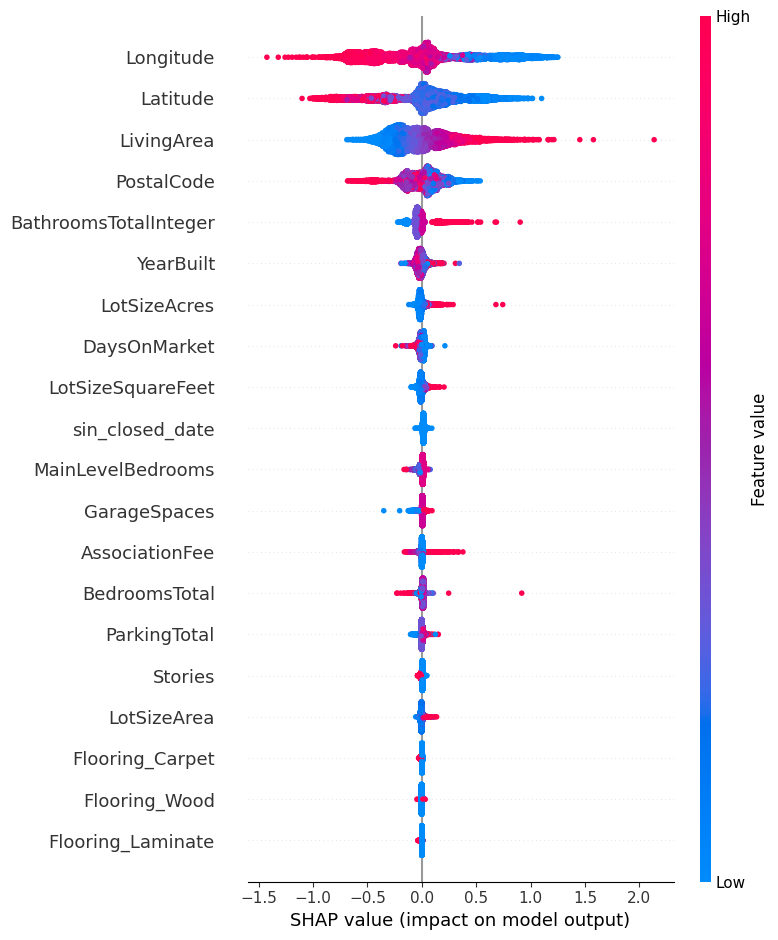

In [14]:
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

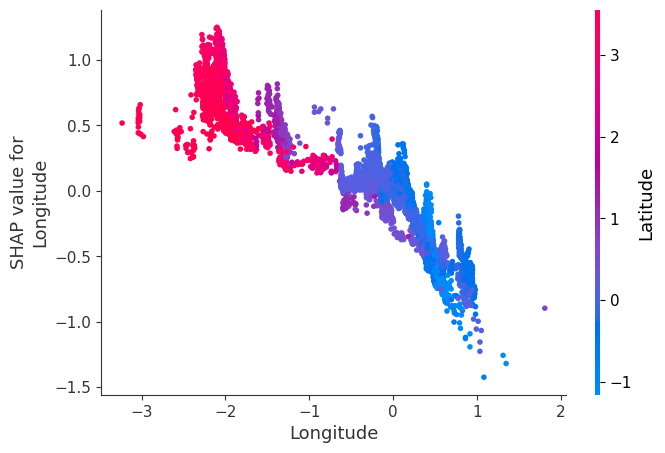

In [19]:
shap.dependence_plot("Longitude", shap_values, X_test)

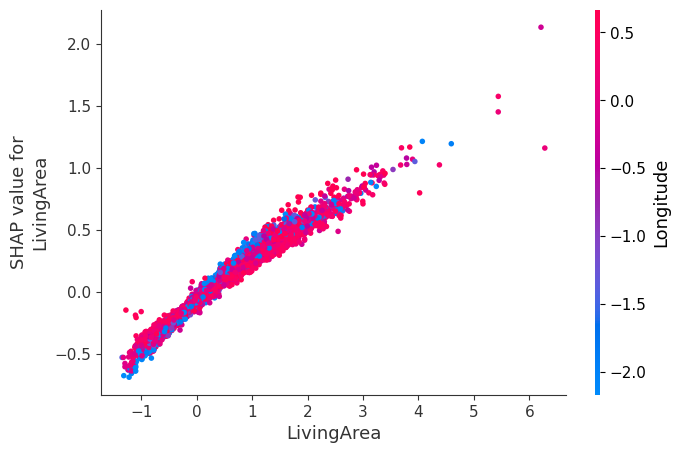

In [16]:
shap.dependence_plot("LivingArea", shap_values, X_test)